# Crude Oil Price Prediction
# Models: Multiple Linear Regression and Random Forest
# Dataset: Daily Crude Oil Prices 2000-2024

In [1]:
# ================================================
# CELL 2 — IMPORT LIBRARIES
# ================================================
# We import all the tools/libraries we need
# Think of these like apps we need to open before working

import pandas as pd          # pandas = for loading and managing our dataset (like Excel in Python)
import numpy as np           # numpy = for mathematical operations and arrays
import matplotlib.pyplot as plt  # matplotlib = for creating graphs and charts
import seaborn as sns        # seaborn = for prettier/more advanced visualizations

# These are specifically for our ML models
from sklearn.linear_model import LinearRegression      # our first model: Multiple Linear Regression
from sklearn.ensemble import RandomForestRegressor     # our second model: Random Forest
from sklearn.model_selection import train_test_split   # for splitting data into training and testing sets
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # for measuring model accuracy

import warnings
warnings.filterwarnings('ignore')  # hides unnecessary warning messages so output is clean

print("All libraries imported successfully!")  # confirms everything loaded without errors

All libraries imported successfully!


In [5]:
# ================================================
# CELL 3 — LOAD THE DATASET
# ================================================
# We load our CSV file into Python using pandas
# pd.read_csv() reads the file and stores it as a "DataFrame"
# A DataFrame is like a table/spreadsheet inside Python

df = pd.read_csv('../data/crude_oil_data.csv')  # replace with your actual file path
print("Dataset loaded successfully!")  # confirms the file was read without errors

# Let's see the first 5 rows of the dataset
# This is like opening the Excel file and peeking at the top rows
print("First 5 rows of the dataset:")
print(df.head())

# Let's also check how many rows and columns we have
# This tells us the "shape" of our data (rows, columns)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset loaded successfully!
First 5 rows of the dataset:
                        Date  Adj_Close      Close       High        Low  \
0  2000-08-23 00:00:00+00:00  32.049999  32.049999  32.799999  31.950001   
1  2000-08-24 00:00:00+00:00  31.629999  31.629999  32.240002  31.400000   
2  2000-08-25 00:00:00+00:00  32.049999  32.049999  32.099998  31.320000   
3  2000-08-28 00:00:00+00:00  32.869999  32.869999  32.919998  31.860001   
4  2000-08-29 00:00:00+00:00  32.720001  32.720001  33.029999  32.560001   

        Open  Volume  
0  31.950001   79385  
1  31.900000   72978  
2  31.700001   44601  
3  32.040001   46770  
4  32.820000   49131  

Dataset Shape: (6073, 7)
Total Rows: 6073
Total Columns: 7


In [7]:
# ================================================
# CELL 4 — DATA EXPLORATION
# ================================================
# Before building models, we need to UNDERSTAND our data
# This is called Exploratory Data Analysis (EDA)

# Check column names and data types
# This tells us what kind of data each column holds
print("Column Names and Data Types:")
print(df.dtypes)

# Check for missing values
# Missing values can break our model so we need to find them first
print("\nMissing Values Per Column:")
print(df.isnull().sum())

# Basic statistics of the dataset
# This shows min, max, average, etc. for each column
print("\nBasic Statistics:")
print(df.describe())

Column Names and Data Types:
Date             str
Adj_Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

Missing Values Per Column:
Date         0
Adj_Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Basic Statistics:
         Adj_Close        Close         High          Low         Open  \
count  6073.000000  6073.000000  6073.000000  6073.000000  6073.000000   
mean     64.626465    64.626465    65.632223    63.564324    64.634843   
std      25.147706    25.147706    25.407970    24.842364    25.140169   
min     -37.630001   -37.630001    13.690000   -40.320000   -14.000000   
25%      45.520000    45.520000    46.470001    44.549999    45.509998   
50%      63.459999    63.459999    64.330002    62.639999    63.500000   
75%      82.919998    82.919998    84.120003    81.760002    83.050003   
max     145.289993   145.289993   147.270004   143.22

In [8]:
# ================================================
# CELL 5 — DATA CLEANING
# ================================================

# Convert Date column from plain text (string) to proper datetime format
# This lets Python understand and sort dates correctly
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# Sort the data by date from oldest to newest
# Important for time series data to be in order
df = df.sort_values('Date').reset_index(drop=True)

# Extract useful time-based features from the date
# These become additional input features for our model
df['Year'] = df['Date'].dt.year    # extracts the year (2000, 2001, etc.)
df['Month'] = df['Date'].dt.month  # extracts the month (1-12)
df['Day'] = df['Date'].dt.day      # extracts the day (1-31)

# Confirm changes
print("Date column after conversion:")
print(df['Date'].head())

print("\nNew columns added:")
print(df[['Date', 'Year', 'Month', 'Day']].head())

print("\nDataset shape after cleaning:")
print(df.shape)

Date column after conversion:
0   2000-08-23 00:00:00+00:00
1   2000-08-24 00:00:00+00:00
2   2000-08-25 00:00:00+00:00
3   2000-08-28 00:00:00+00:00
4   2000-08-29 00:00:00+00:00
Name: Date, dtype: datetime64[us, UTC]

New columns added:
                       Date  Year  Month  Day
0 2000-08-23 00:00:00+00:00  2000      8   23
1 2000-08-24 00:00:00+00:00  2000      8   24
2 2000-08-25 00:00:00+00:00  2000      8   25
3 2000-08-28 00:00:00+00:00  2000      8   28
4 2000-08-29 00:00:00+00:00  2000      8   29

Dataset shape after cleaning:
(6073, 10)


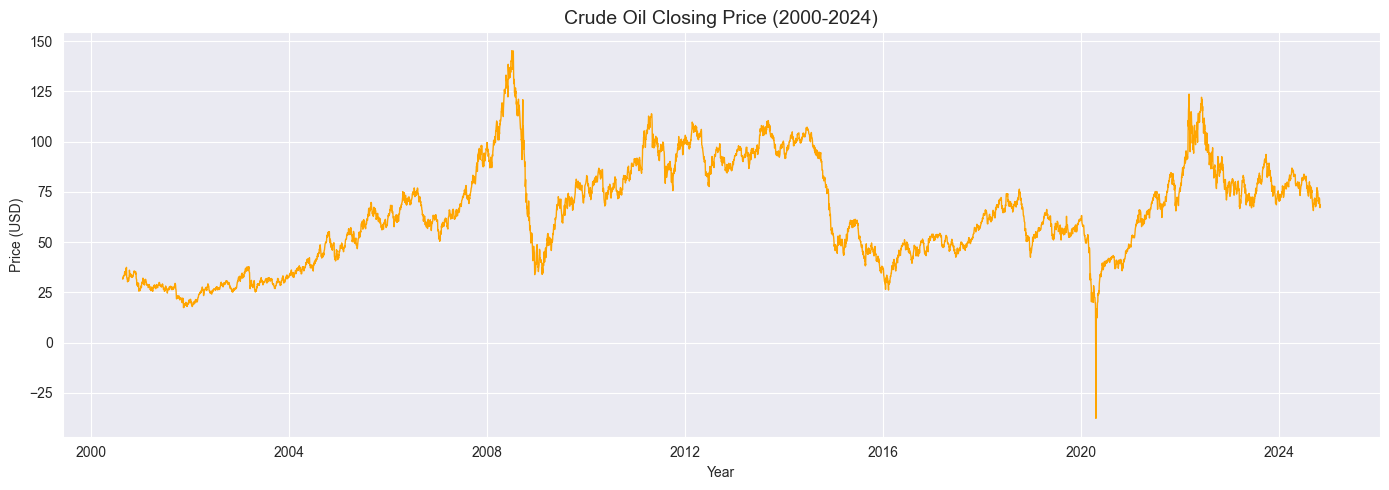

Graph 1 saved!


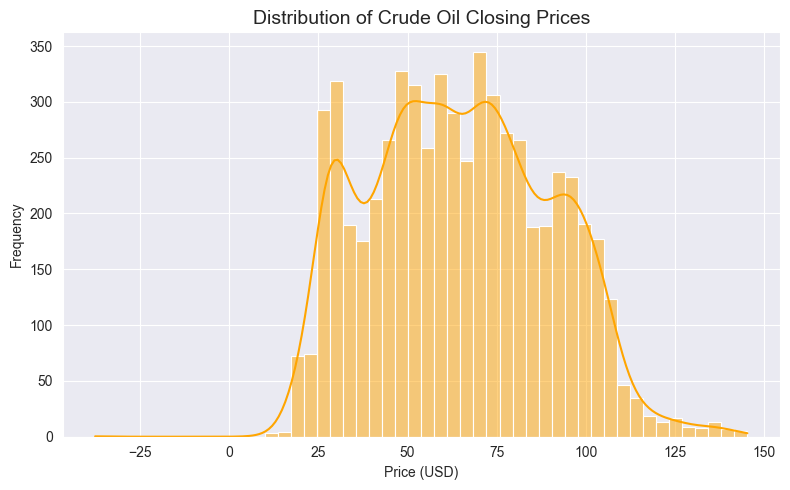

Graph 2 saved!


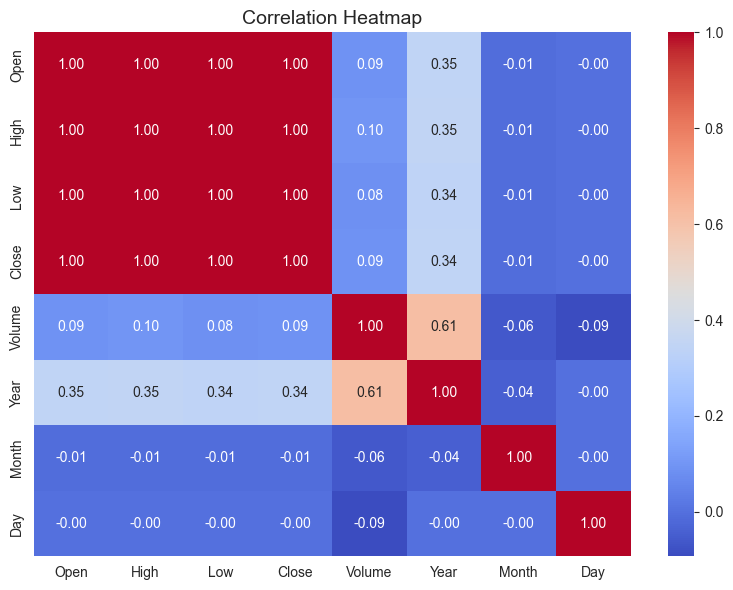

Graph 3 saved!


In [9]:
# ================================================
# CELL 6 — DATA VISUALIZATION
# ================================================

# Set the visual style for all our graphs
sns.set_style("darkgrid")

# ---- GRAPH 1: Crude Oil Price Over Time ----
# This shows how oil prices changed from 2000 to 2024
# We can visually see crashes (2008, 2020) and spikes (2022)
plt.figure(figsize=(14, 5))           # set the size of the graph
plt.plot(df['Date'], df['Close'],      # x-axis = date, y-axis = closing price
         color='orange', linewidth=1)  # orange line, thin width
plt.title('Crude Oil Closing Price (2000-2024)', fontsize=14)  # graph title
plt.xlabel('Year')                     # x-axis label
plt.ylabel('Price (USD)')              # y-axis label
plt.tight_layout()
plt.savefig('../outputs/oil_price_over_time.png')  # save graph to outputs folder
plt.show()
print("Graph 1 saved!")

# ---- GRAPH 2: Distribution of Closing Prices ----
# This shows how frequently each price range occurred
# A histogram helps us understand the shape of our data
plt.figure(figsize=(8, 5))
sns.histplot(df['Close'], bins=50, color='orange', kde=True)
# kde=True adds a smooth curve on top of the histogram
plt.title('Distribution of Crude Oil Closing Prices', fontsize=14)
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/price_distribution.png')  # save to outputs folder
plt.show()
print("Graph 2 saved!")

# ---- GRAPH 3: Correlation Heatmap ----
# This shows how strongly each column relates to our target (Close price)
# Values close to 1.0 = strong relationship
# Values close to 0.0 = weak relationship
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume', 'Year', 'Month', 'Day']].corr(),
            annot=True,      # show the numbers inside each box
            cmap='coolwarm', # color scheme
            fmt='.2f')       # round to 2 decimal places
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')  # save to outputs folder
plt.show()
print("Graph 3 saved!")

In [10]:
# ================================================
# CELL 7 — PREPARE FEATURES (X) AND TARGET (Y)
# ================================================

# In machine learning:
# X = input features (what we use to predict)
# y = target variable (what we want to predict)

# Based on our heatmap, Open, High, Low have perfect correlation
# Volume and Year have moderate correlation
# We DROP Month and Day since they have near-zero correlation

# Define our input features (X)
X = df[['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day']]

# Define our target variable (y) — what we're predicting
y = df['Close']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns we are using:")
print(X.columns.tolist())
print("\nFirst 5 rows of X:")
print(X.head())

Features (X) shape: (6073, 7)
Target (y) shape: (6073,)

Feature columns we are using:
['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day']

First 5 rows of X:
        Open       High        Low  Volume  Year  Month  Day
0  31.950001  32.799999  31.950001   79385  2000      8   23
1  31.900000  32.240002  31.400000   72978  2000      8   24
2  31.700001  32.099998  31.320000   44601  2000      8   25
3  32.040001  32.919998  31.860001   46770  2000      8   28
4  32.820000  33.029999  32.560001   49131  2000      8   29


In [11]:
# ================================================
# CELL 8 — SPLIT DATA INTO TRAINING AND TESTING SETS
# ================================================

# We split our data into two parts:
# - Training set (80%) = what the model LEARNS from
# - Testing set  (20%) = what we use to TEST how well it learned
# This is like studying (training) then taking an exam (testing)

# test_size=0.2 means 20% goes to testing, 80% to training
# random_state=42 ensures we get the same split every time we run
# (makes our results reproducible — important for the paper!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Let's confirm the sizes of each split
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print(f"\nTraining rows: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing rows:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set size: (4858, 7)
Testing set size: (1215, 7)

Training rows: 4858 (80.0%)
Testing rows:  1215 (20.0%)


In [12]:
# ================================================
# CELL 9 — MULTIPLE LINEAR REGRESSION (MLR)
# ================================================

# MLR is our BASELINE model — the simplest one
# It tries to find a straight-line relationship between
# our input features (X) and the target price (y)
# Formula: Close = b0 + b1(Open) + b2(High) + b3(Low) + ...

# STEP 1: Create the model
mlr_model = LinearRegression()  # create an empty MLR model

# STEP 2: Train the model
# .fit() = the model LEARNS the patterns from training data
mlr_model.fit(X_train, y_train)
print("MLR Model trained successfully!")

# STEP 3: Make predictions on the TEST set
# .predict() = the model GUESSES the price based on what it learned
mlr_predictions = mlr_model.predict(X_test)

# STEP 4: Evaluate the model performance
# We use 3 metrics to measure how good our predictions are:

# MAE (Mean Absolute Error) = average error in dollars
# Lower is better — e.g. MAE of 2.5 means predictions are off by $2.50 on average
mlr_mae = mean_absolute_error(y_test, mlr_predictions)

# RMSE (Root Mean Squared Error) = penalizes large errors more
# Lower is better
mlr_rmse = np.sqrt(mean_squared_error(y_test, mlr_predictions))

# R² (R-squared) = how well the model explains the data
# Closer to 1.0 = better (1.0 = perfect, 0.0 = terrible)
mlr_r2 = r2_score(y_test, mlr_predictions)

print("\n--- MLR Model Performance ---")
print(f"MAE  (Mean Absolute Error):        ${mlr_mae:.4f}")
print(f"RMSE (Root Mean Squared Error):    ${mlr_rmse:.4f}")
print(f"R²   (R-squared Score):            {mlr_r2:.4f}")

# STEP 5: Show the model coefficients
# These tell us how much each feature influences the prediction
print("\n--- MLR Coefficients ---")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})
print(coefficients)
print(f"\nIntercept: {mlr_model.intercept_:.4f}")

MLR Model trained successfully!

--- MLR Model Performance ---
MAE  (Mean Absolute Error):        $0.3721
RMSE (Root Mean Squared Error):    $0.5252
R²   (R-squared Score):            0.9996

--- MLR Coefficients ---
  Feature   Coefficient
0    Open -6.661618e-01
1    High  7.865277e-01
2     Low  8.815628e-01
3  Volume  1.185948e-08
4    Year -2.344589e-04
5   Month -3.291979e-03
6     Day  2.759602e-03

Intercept: 0.4730


In [14]:
# ================================================
# CELL 9B — FIX DATA LEAKAGE USING LAG FEATURES
# ================================================

# We create "lag" features — these are previous day's values
# .shift(1) moves all values DOWN by 1 row
# So row 5's "Prev_Close" = row 4's actual Close price
# This simulates REAL prediction: using yesterday to predict today

df['Prev_Close'] = df['Close'].shift(1)   # yesterday's closing price
df['Prev_High'] = df['High'].shift(1)     # yesterday's highest price
df['Prev_Low'] = df['Low'].shift(1)       # yesterday's lowest price
df['Prev_Open'] = df['Open'].shift(1)     # yesterday's opening price
df['Prev_Volume'] = df['Volume'].shift(1) # yesterday's trading volume

# The first row will now have NaN (no "previous day" exists)
# So we drop that row
df = df.dropna().reset_index(drop=True)

# Redefine X using ONLY previous day's data (no leakage!)
X = df[['Prev_Open', 'Prev_High', 'Prev_Low', 'Prev_Volume', 'Year', 'Month', 'Day']]
y = df['Close']  # today's closing price (what we predict)

# Re-split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Features updated with lag values!")
print("New X shape:", X.shape)
print("\nFirst 5 rows of new X:")
print(X.head())

Features updated with lag values!
New X shape: (6071, 7)

First 5 rows of new X:
   Prev_Open  Prev_High   Prev_Low  Prev_Volume  Year  Month  Day
0  31.900000  32.240002  31.400000      72978.0  2000      8   25
1  31.700001  32.099998  31.320000      44601.0  2000      8   28
2  32.040001  32.919998  31.860001      46770.0  2000      8   29
3  32.820000  33.029999  32.560001      49131.0  2000      8   30
4  32.750000  33.400002  32.099998      79214.0  2000      8   31


In [15]:
# ================================================
# CELL 10 — RETRAIN MLR WITH CLEAN LAG FEATURES
# ================================================

# Now we retrain MLR using ONLY previous day's data
# This is a REALISTIC model — predicting tomorrow using today's info

# STEP 1: Create and train the model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)
print("MLR Model retrained successfully!")

# STEP 2: Make predictions
mlr_predictions = mlr_model.predict(X_test)

# STEP 3: Evaluate performance
mlr_mae  = mean_absolute_error(y_test, mlr_predictions)
mlr_rmse = np.sqrt(mean_squared_error(y_test, mlr_predictions))
mlr_r2   = r2_score(y_test, mlr_predictions)

print("\n--- MLR Model Performance (After Fix) ---")
print(f"MAE  (Mean Absolute Error):     ${mlr_mae:.4f}")
print(f"RMSE (Root Mean Squared Error): ${mlr_rmse:.4f}")
print(f"R²   (R-squared Score):         {mlr_r2:.4f}")

# STEP 4: Show coefficients
# These show how much each previous day's feature influences today's price
print("\n--- MLR Coefficients ---")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})
print(coefficients)
print(f"\nIntercept: {mlr_model.intercept_:.4f}")

MLR Model retrained successfully!

--- MLR Model Performance (After Fix) ---
MAE  (Mean Absolute Error):     $1.1192
RMSE (Root Mean Squared Error): $1.6248
R²   (R-squared Score):         0.9960

--- MLR Coefficients ---
       Feature   Coefficient
0    Prev_Open -4.034218e-01
1    Prev_High  8.279632e-01
2     Prev_Low  5.718947e-01
3  Prev_Volume -2.111278e-07
4         Year  6.362286e-04
5        Month -2.108190e-02
6          Day  5.905887e-03

Intercept: -1.1599


In [16]:
# ================================================
# CELL 11 — RANDOM FOREST MODEL
# ================================================

# Random Forest builds MANY decision trees (a "forest")
# and averages their predictions for better accuracy
# It handles non-linear patterns much better than MLR

# STEP 1: Create the Random Forest model
# n_estimators=100 = build 100 decision trees
# random_state=42  = ensures reproducibility
rf_model = RandomForestRegressor(
    n_estimators=100,  # number of trees in the forest
    random_state=42,   # for reproducibility
    n_jobs=-1          # use all CPU cores to train faster
)

# STEP 2: Train the model
# This takes a bit longer than MLR because it builds 100 trees!
print("Training Random Forest... please wait...")
rf_model.fit(X_train, y_train)
print("Random Forest Model trained successfully!")

# STEP 3: Make predictions
rf_predictions = rf_model.predict(X_test)

# STEP 4: Evaluate performance
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2   = r2_score(y_test, rf_predictions)

print("\n--- Random Forest Model Performance ---")
print(f"MAE  (Mean Absolute Error):     ${rf_mae:.4f}")
print(f"RMSE (Root Mean Squared Error): ${rf_rmse:.4f}")
print(f"R²   (R-squared Score):         {rf_r2:.4f}")

# STEP 5: Feature Importance
# Random Forest can tell us WHICH features mattered most
# This is one of its biggest advantages over MLR!
print("\n--- Feature Importance ---")
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df)

Training Random Forest... please wait...
Random Forest Model trained successfully!

--- Random Forest Model Performance ---
MAE  (Mean Absolute Error):     $1.2248
RMSE (Root Mean Squared Error): $1.8432
R²   (R-squared Score):         0.9948

--- Feature Importance ---
       Feature  Importance
1    Prev_High    0.593650
2     Prev_Low    0.400678
0    Prev_Open    0.003732
3  Prev_Volume    0.000739
6          Day    0.000584
5        Month    0.000356
4         Year    0.000261


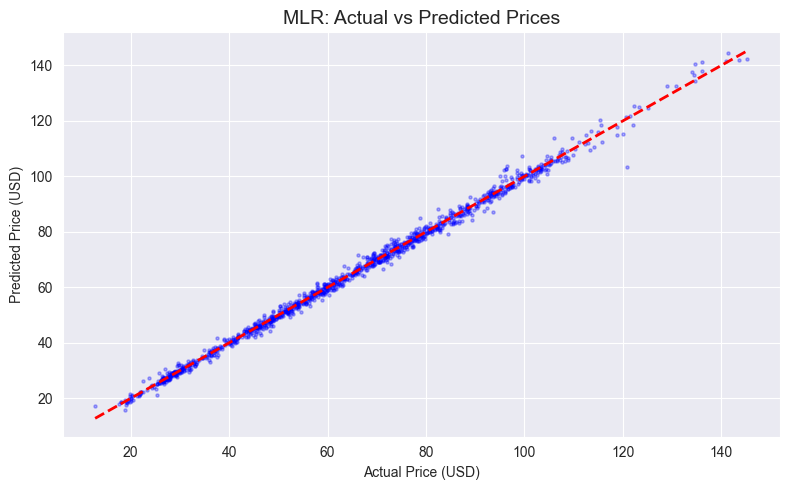

Graph 4 saved!


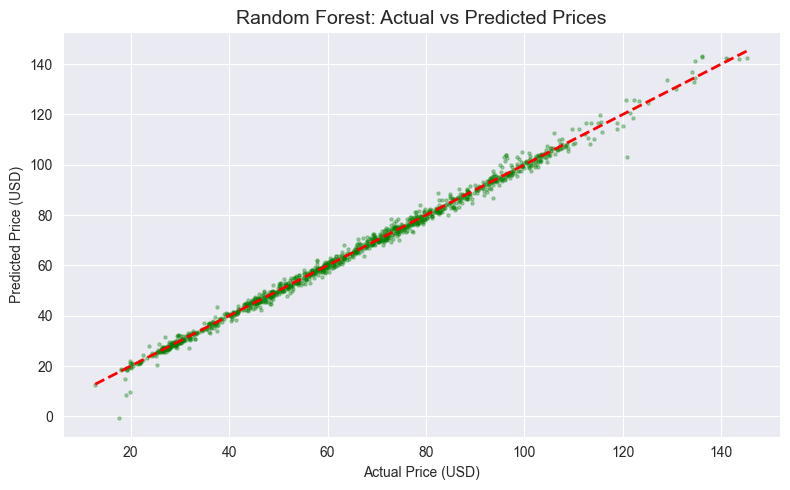

Graph 5 saved!


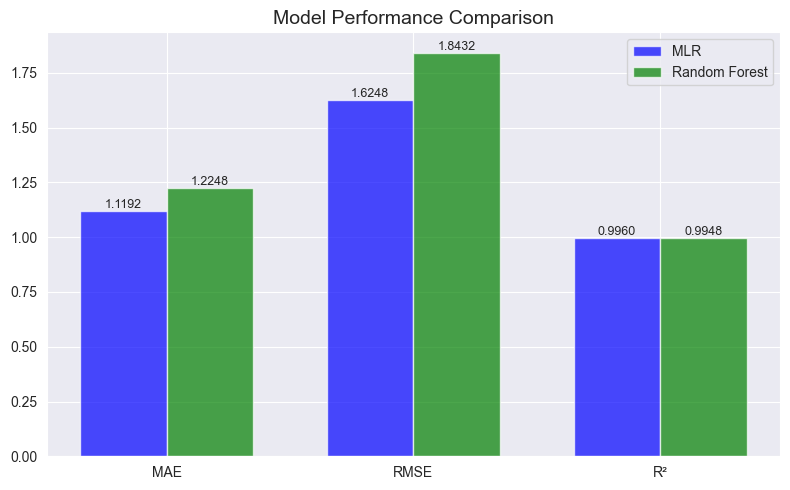

Graph 6 saved!


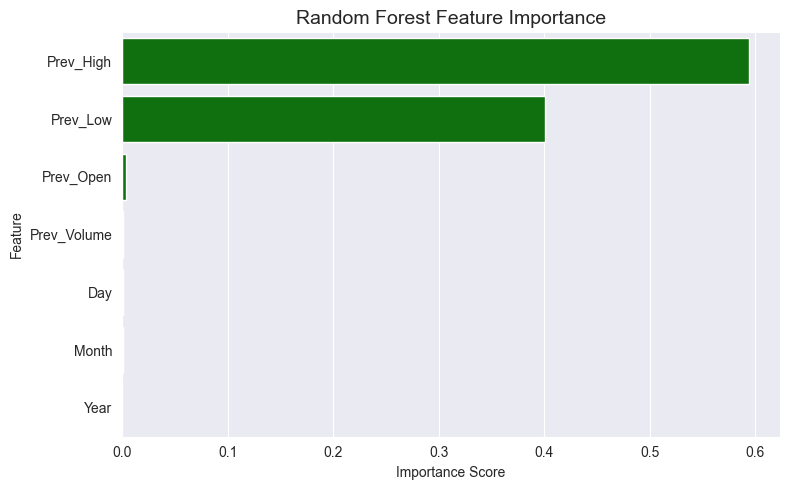

Graph 7 saved!


In [17]:
# ================================================
# CELL 12 — MODEL COMPARISON VISUALIZATION
# ================================================

# ---- GRAPH 4: Actual vs Predicted (MLR) ----
# This shows how close our MLR predictions are to real prices
# Perfect model = all points on the diagonal line
plt.figure(figsize=(8, 5))
plt.scatter(y_test, mlr_predictions,
            alpha=0.3,        # transparency so overlapping points are visible
            color='blue',
            s=5)              # small dot size
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)  # red diagonal = perfect prediction line
plt.title('MLR: Actual vs Predicted Prices', fontsize=14)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.tight_layout()
plt.savefig('../outputs/mlr_actual_vs_predicted.png')
plt.show()
print("Graph 4 saved!")

# ---- GRAPH 5: Actual vs Predicted (Random Forest) ----
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_predictions,
            alpha=0.3,
            color='green',
            s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.title('Random Forest: Actual vs Predicted Prices', fontsize=14)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.tight_layout()
plt.savefig('../outputs/rf_actual_vs_predicted.png')
plt.show()
print("Graph 5 saved!")

# ---- GRAPH 6: Side by Side Model Comparison ----
# Bar chart comparing MAE, RMSE, R² of both models
metrics = ['MAE', 'RMSE', 'R²']
mlr_scores = [mlr_mae, mlr_rmse, mlr_r2]
rf_scores  = [rf_mae,  rf_rmse,  rf_r2]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, mlr_scores, width,
               label='MLR', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, rf_scores,  width,
               label='Random Forest', color='green', alpha=0.7)

ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()
print("Graph 6 saved!")

# ---- GRAPH 7: Feature Importance (Random Forest) ----
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature',
            data=importance_df, color='green')
plt.title('Random Forest Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()
print("Graph 7 saved!")

In [18]:
# ================================================
# CELL 13 — FINAL RESULTS SUMMARY
# ================================================

print("=" * 50)
print("   CRUDE OIL PRICE PREDICTION - FINAL RESULTS")
print("=" * 50)

print(f"""
┌─────────────────────────────────────────────┐
│           MODEL PERFORMANCE SUMMARY          │
├──────────────┬──────────┬──────────┬────────┤
│   Model      │   MAE    │   RMSE   │   R²   │
├──────────────┼──────────┼──────────┼────────┤
│ MLR          │ ${mlr_mae:.4f} │ ${mlr_rmse:.4f} │ {mlr_r2:.4f}│
│ Random Forest│ ${rf_mae:.4f} │ ${rf_rmse:.4f} │ {rf_r2:.4f}│
└──────────────┴──────────┴──────────┴────────┘
""")

# Determine winner
if mlr_r2 > rf_r2:
    print("🏆 WINNER: Multiple Linear Regression")
    print("   Reason: MLR outperformed Random Forest on this")
    print("   dataset, suggesting crude oil prices follow")
    print("   a strong linear pattern day-to-day.")
else:
    print("🏆 WINNER: Random Forest")

print("\n✅ All models trained and evaluated successfully!")
print("✅ All graphs saved to outputs/ folder!")
print("✅ Ready for paper writing!")

   CRUDE OIL PRICE PREDICTION - FINAL RESULTS

┌─────────────────────────────────────────────┐
│           MODEL PERFORMANCE SUMMARY          │
├──────────────┬──────────┬──────────┬────────┤
│   Model      │   MAE    │   RMSE   │   R²   │
├──────────────┼──────────┼──────────┼────────┤
│ MLR          │ $1.1192 │ $1.6248 │ 0.9960│
│ Random Forest│ $1.2248 │ $1.8432 │ 0.9948│
└──────────────┴──────────┴──────────┴────────┘

🏆 WINNER: Multiple Linear Regression
   Reason: MLR outperformed Random Forest on this
   dataset, suggesting crude oil prices follow
   a strong linear pattern day-to-day.

✅ All models trained and evaluated successfully!
✅ All graphs saved to outputs/ folder!
✅ Ready for paper writing!
